# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("AB_NYC_2019.csv")

# Display first rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [ ]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData types:\n")
print(df.dtypes)

# Basic statistics
df.describe()

# Check categorical columns
df.describe(include='object')

Shape of dataset: (48895, 16)

Data types:

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


**✍️ Your Interpretation:**

Size: 48,895 rows × 16 columns

Numerical columns: 10

Categorical columns: 6

reviews_per_month and last_review have many missing values

The dataset appears mostly clean but contains missing values and outliers.

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [ ]:
# Count missing values
missing = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [ ]:
# Handling the missing values:
# Fill reviews_per_month with 0
df["reviews_per_month"].fillna(0, inplace=True)

# Drop rows with missing name or host_name
df.dropna(subset=["name", "host_name"], inplace=True)

**✍️ Your Interpretation:**
Fill reviews_per_month with 0 for listings without reviews.

Drop rows with missing names.


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [ ]:
# Check full duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate IDs
print("Duplicate listing IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate listing IDs: 0


**✍️ Your Interpretation:**

Duplicate rows: 0

Duplicate id: 0

Each listing ID appears exactly once, confirming that the dataset contains unique listings.

No duplication problems.


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


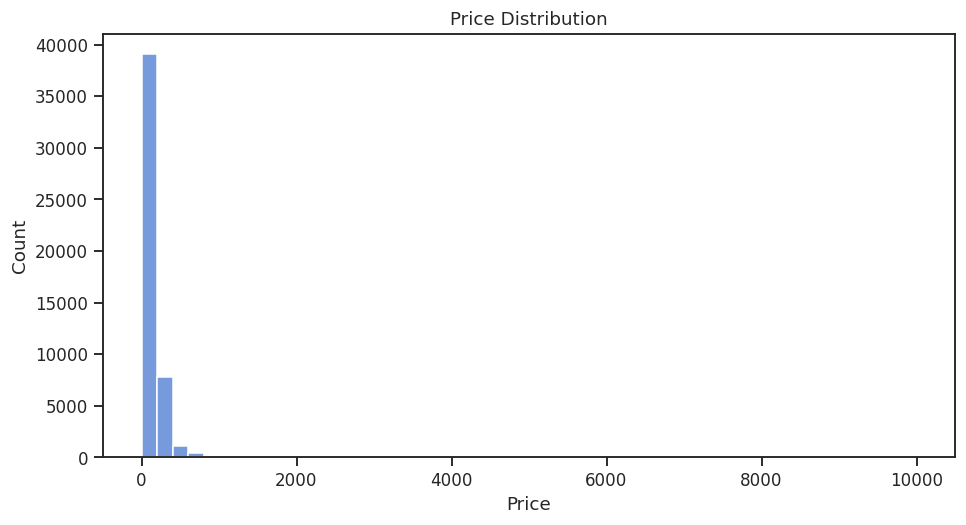

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [ ]:
#Listings with price 0
zero_price = (df["price"] == 0).sum()
print("Listings with price = 0:", zero_price)

Listings with price = 0: 11


In [ ]:
df = df[df["price"] > 0]
df = df[df["price"] < 1000]

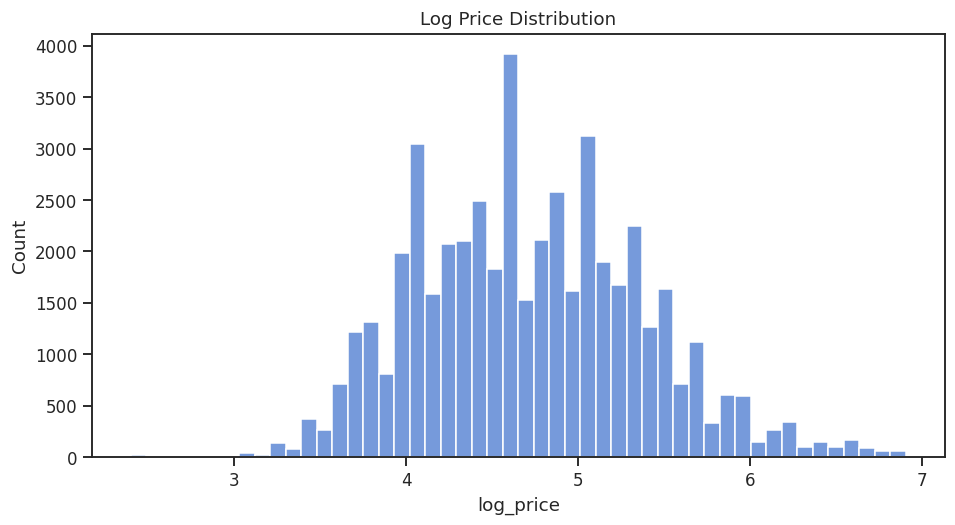

In [ ]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10,5))
sns.histplot(df["log_price"], bins=50)

plt.title("Log Price Distribution")
plt.show()

**✍️ Your Interpretation:**

First of all graph was observed as it was observed that there is high skewness in graph due to price values.

11 Listings were with price 0.

Then we took price values greater than 0 and less than 1000 to normalize it.

Moreover by applying a log(price) transformation makes the distribution closer to normal and easier to analyze.

### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


In [ ]:
# Median price
median_price = df.groupby("neighbourhood_group")["price"].median()

# Mean price
mean_price = df.groupby("neighbourhood_group")["price"].mean()

print("Median Price:\n", median_price)
print("\nMean Price:\n", mean_price)

Median Price:
 neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        149.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

Mean Price:
 neighbourhood_group
Bronx             84.488029
Brooklyn         117.310348
Manhattan        177.380512
Queens            94.544682
Staten Island     96.148649
Name: price, dtype: float64


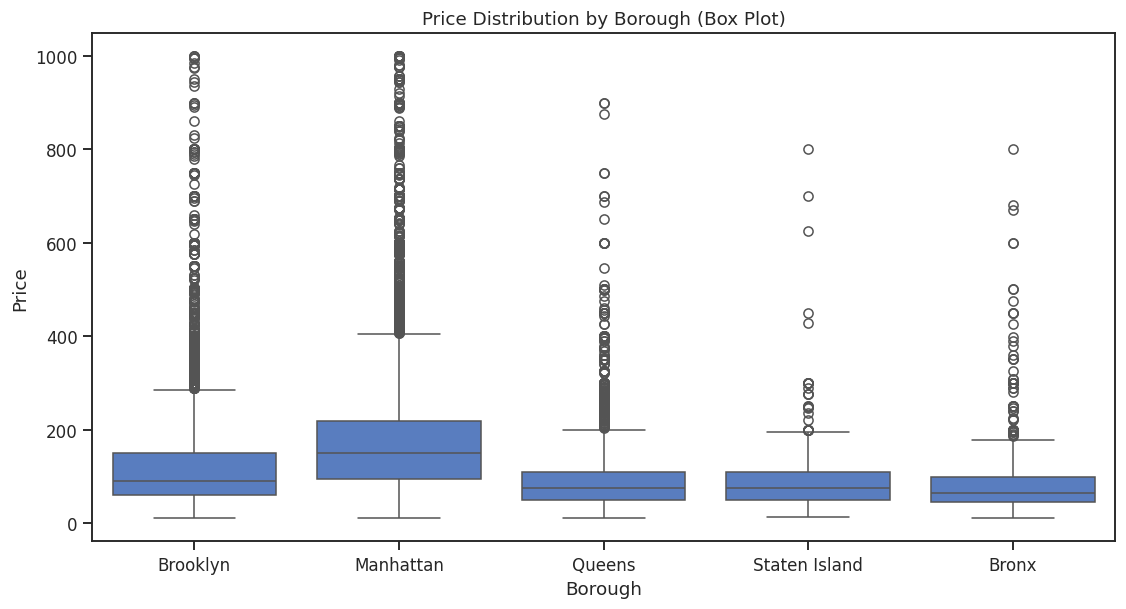

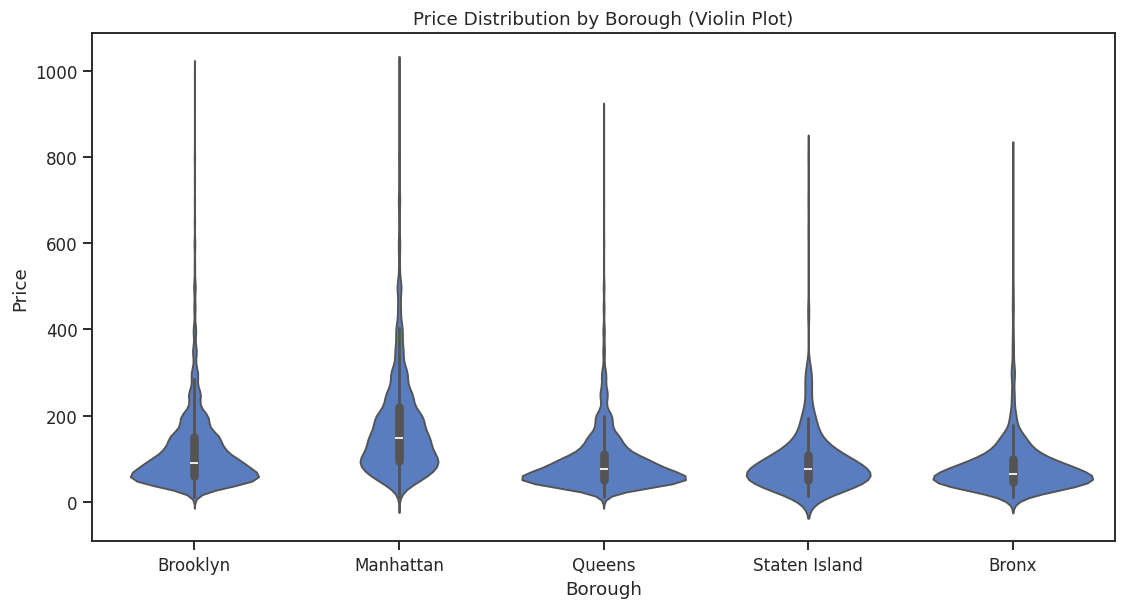

In [ ]:
#Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x="neighbourhood_group", y="price", data=df)
plt.title("Price Distribution by Borough (Box Plot)")
plt.xlabel("Borough")
plt.ylabel("Price")
plt.show()

# Violin Plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="neighbourhood_group", y="price", data=df)
plt.title("Price Distribution by Borough (Violin Plot)")
plt.xlabel("Borough")
plt.ylabel("Price")
plt.show()

**✍️ Your Interpretation:**  

Manhattan is the most expensive borough by both mean and median.

Price Variability:

Manhattan shows the highest variability, meaning prices vary widely from budget rooms to luxury apartments.

Higher variability = higher potential returns but also higher risk.


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


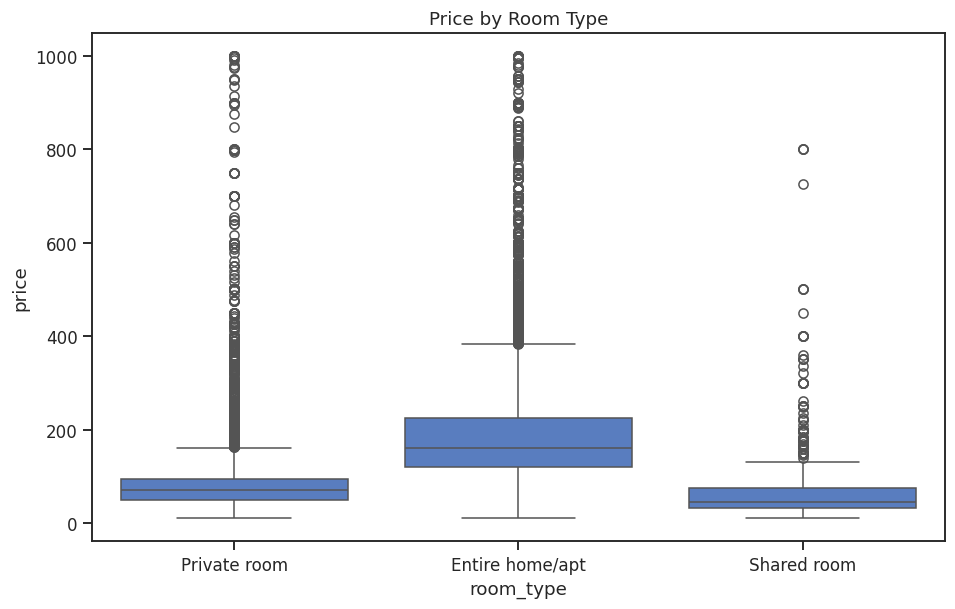

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="room_type",
    y="price",
    data=df
)

plt.title("Price by Room Type")

plt.show()

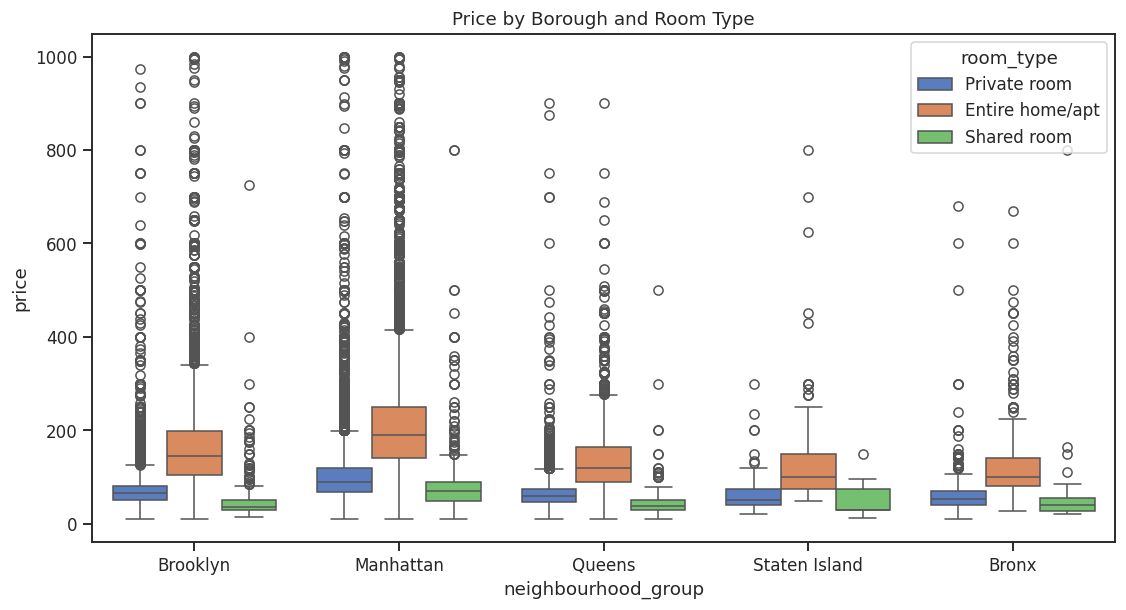

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    hue="room_type",
    data=df
)

plt.title("Price by Borough and Room Type")

plt.show()

**✍️ Your Interpretation:**  

Shared rooms are the cheapest option.

Good value options:

Private rooms in Brooklyn

Entire homes in Queens


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


In [ ]:
host_counts = df.groupby("host_id").size()

# Number of listings per host
host_counts.describe()

,0
count,37205.000000
mean,1.304905
std,2.765419
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,327.000000


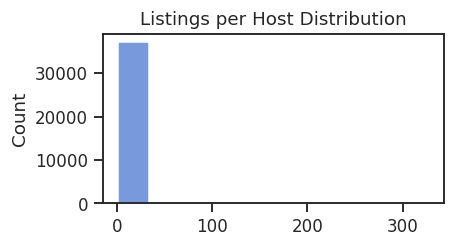

In [ ]:
plt.figure(figsize=(4,2))

sns.histplot(host_counts, bins=10)

plt.title("Listings per Host Distribution")

plt.show()

In [ ]:
multi_hosts = (host_counts > 10).sum()

print("Hosts with > 10 listings:", multi_hosts)

Hosts with > 10 listings: 91


**✍️ Your Interpretation:**  

Hosts with 1 listing = ~86%

Hosts with >10 listings = ~0.25%

Top 1% of hosts control ~10% of listings.


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


In [ ]:
# Convert last_review to datetime
df["last_review"] = pd.to_datetime(df["last_review"])

snapshot_date = pd.to_datetime("2019-07-08")

df["days_since_review"] = (snapshot_date - df["last_review"]).dt.days

In [ ]:
ghost_year = (df["days_since_review"] > 365).sum()
ghost_six_months = (df["days_since_review"] > 180).sum()

total_listings = len(df)

percent_ghost_year = (ghost_year / total_listings) * 100
percent_ghost_six_months = (ghost_six_months / total_listings) * 100

print(f"Listings with no review in last year: {ghost_year} ({percent_ghost_year:.2f}%)")
print(f"Listings with no review in last 6 months: {ghost_six_months} ({percent_ghost_six_months:.2f}%)")

Listings with no review in last year: 9625 (19.83%)
Listings with no review in last 6 months: 14621 (30.12%)


**✍️ Your Interpretation:**  

Almost one-third of listings appear inactive.


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


In [ ]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)

top_neighbourhoods

,count
neighbourhood,
Williamsburg,3904
Bedford-Stuyvesant,3696
Harlem,2647
Bushwick,2457
Hell's Kitchen,1944
Upper West Side,1939
East Village,1838
Upper East Side,1781
Crown Heights,1560


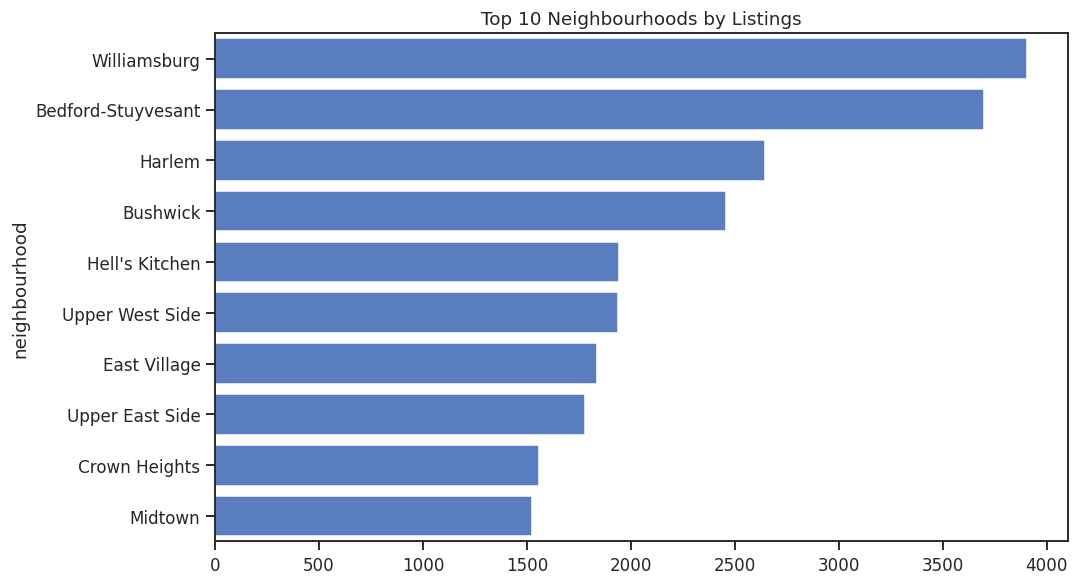

In [ ]:
#Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_neighbourhoods.values,
    y=top_neighbourhoods.index
)

plt.title("Top 10 Neighbourhoods by Listings")

plt.show()

**✍️ Your Interpretation:**  

Brooklyn neighbourhoods dominate listing counts.

Williamsburg = Many listings but moderate prices

Midtown areas = Fewer listings but higher prices.

### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


In [ ]:
long_stays = (df["minimum_nights"] >= 30).sum()
year_stays = (df["minimum_nights"] >= 365).sum()

total_listings = len(df)

percent_30_plus = (long_stays / total_listings) * 100
percent_365 = (year_stays / total_listings) * 100

print("Listings with >=30 nights:", long_stays, f"({percent_30_plus:.2f}%)")
print("Listings with >=365 nights:", year_stays, f"({percent_365:.2f}%)")

Listings with >=30 nights: 4442 (9.15%)
Listings with >=365 nights: 39 (0.08%)


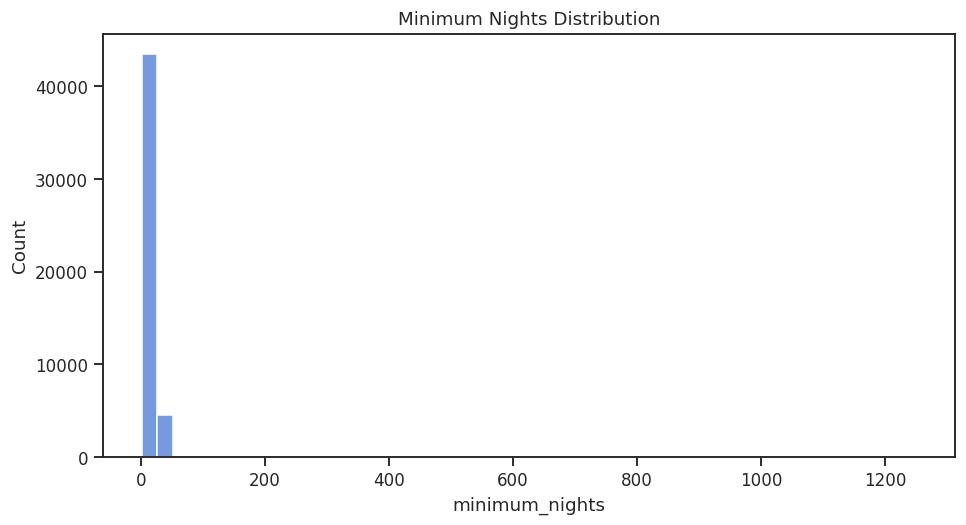

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["minimum_nights"], bins=50)

plt.title("Minimum Nights Distribution")

plt.show()

**✍️ Your Interpretation:**  

Listings with 30+ minimum nights = ~9.2%

Listings with 365-night minimum = 0.08%


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


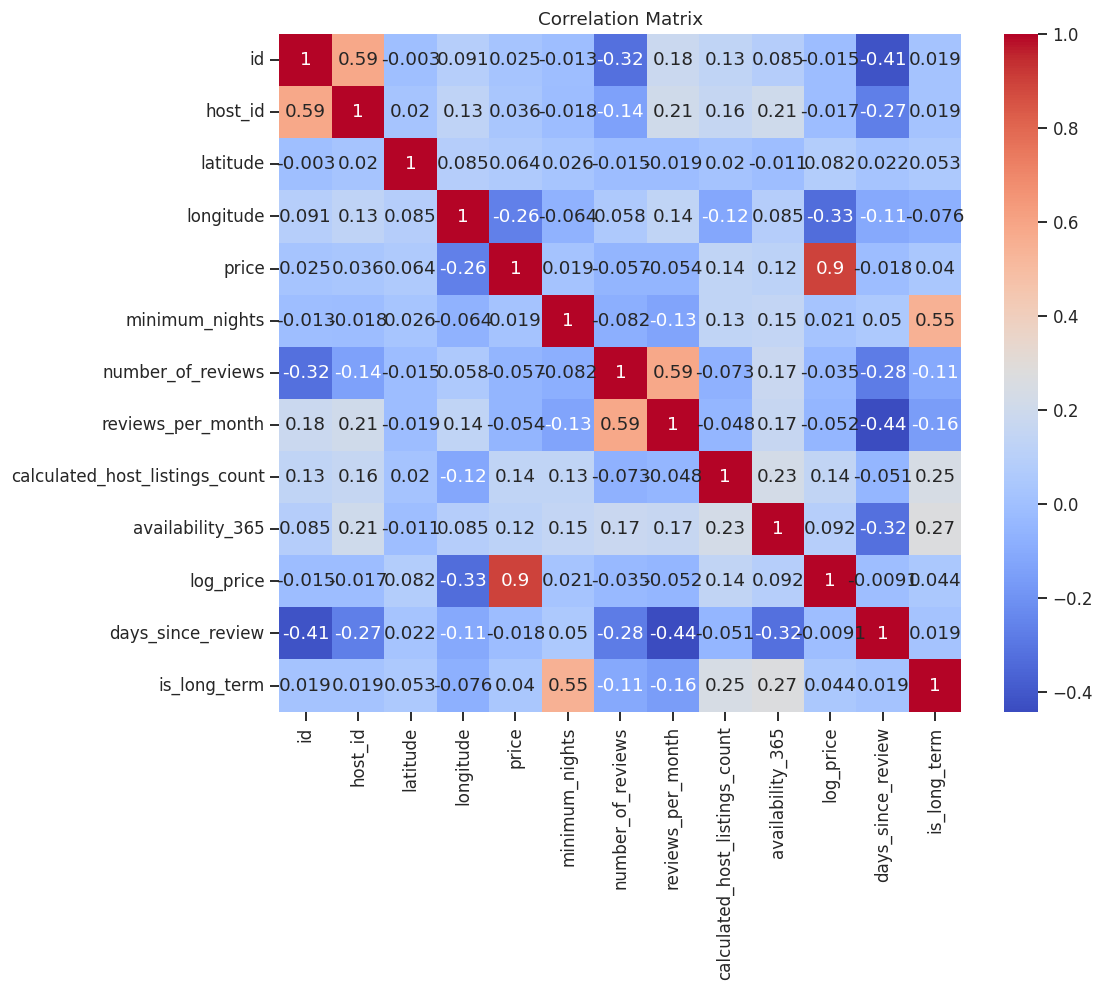

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

**✍️ Your Interpretation:**  

Price has very weak correlation with most variables.

### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


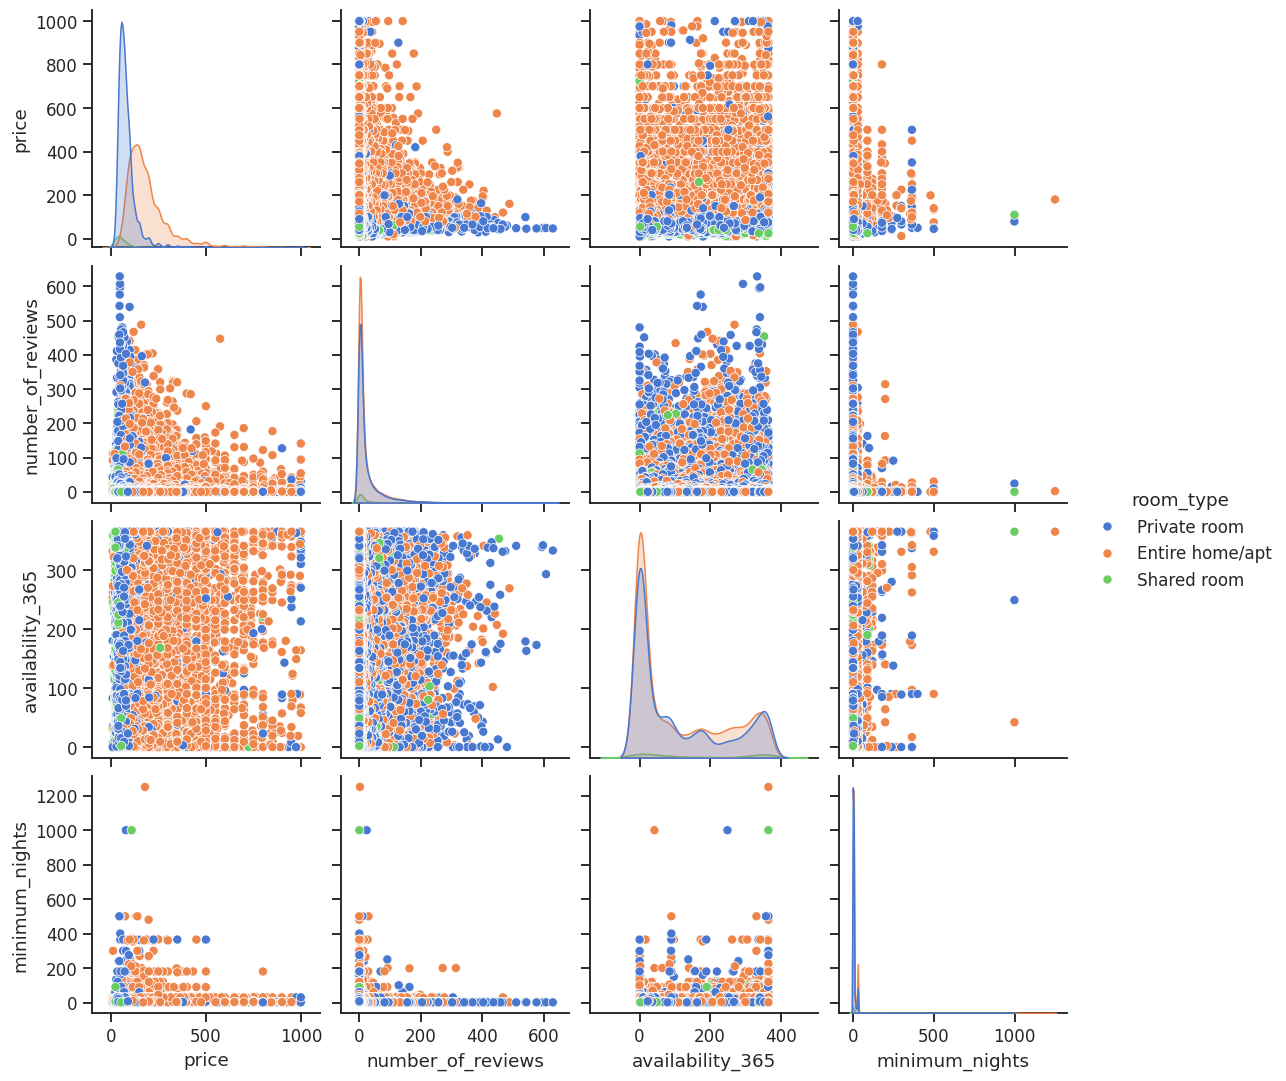

In [ ]:
sns.pairplot(
    df[[
        "price",
        "number_of_reviews",
        "availability_365",
        "minimum_nights",
        "room_type"
    ]],
    hue="room_type"
)

plt.show()

**✍️ Your Interpretation:**

Entire homes cluster at higher prices.

Private rooms cluster at mid-price ranges.

Shared rooms are clearly separated as the cheapest category.


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings

Several data quality issues must be considered before making investment decisions. First, the dataset contains listings with a price of $0 and extreme outliers reaching $10,000, which likely represent data entry errors or luxury anomalies. Second, approximately 20% of listings are missing review information (last_review and reviews_per_month), which likely indicates listings that have never been reviewed or have low activity. Finally, some listings show extremely high minimum-night requirements, including values up to 365 nights, which suggests they function more like long-term rentals rather than typical Airbnb listings.

### Manhattan Investor

Manhattan clearly commands the highest prices in the NYC Airbnb market, with a median listing price around $150. However, the borough also shows the highest variability in pricing, indicating strong competition between budget and luxury listings. While this creates opportunities for high revenue, it also increases risk because investors must differentiate their properties through location, quality, or amenities.


### Brooklyn Investor

Brooklyn has a lower median price (~$90) but a very large number of listings, especially in neighbourhoods like Williamsburg and Bedford-Stuyvesant. This indicates strong demand and an active marketplace. Brooklyn may offer a better balance between affordability and occupancy, making it attractive for investors with smaller budgets.

### Recommendation for Undecided Investor

For investors unsure where to start, Brooklyn may offer the best entry point due to lower property prices and strong demand. Manhattan provides higher potential returns but requires higher capital and faces greater competition.

### What I Would Investigate Next

Future analysis should examine booking frequency, seasonal demand, and regulatory impacts. Additionally, geographic clustering analysis and review sentiment analysis could reveal which neighbourhoods provide the highest long-term profitability.

---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [ ]:
# Count listings per host
host_listing_counts = df.groupby("host_id").size()

# Map listing counts back to dataframe
df["host_listing_count"] = df["host_id"].map(host_listing_counts)

# Define power host (>5 listings)
df["power_host"] = df["host_listing_count"] > 5

# Check counts
df["power_host"].value_counts()

,count
power_host,
False,43812
True,4737


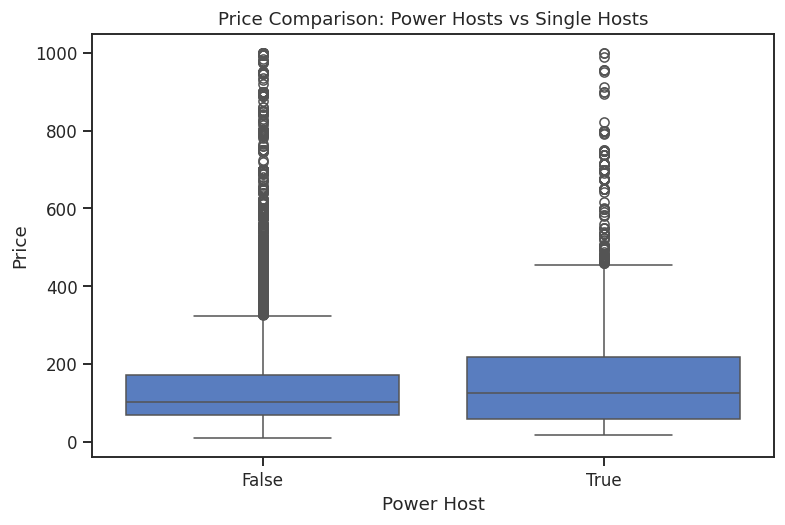

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="power_host",
    y="price",
    data=df
)

plt.title("Price Comparison: Power Hosts vs Single Hosts")
plt.xlabel("Power Host")
plt.ylabel("Price")

plt.show()

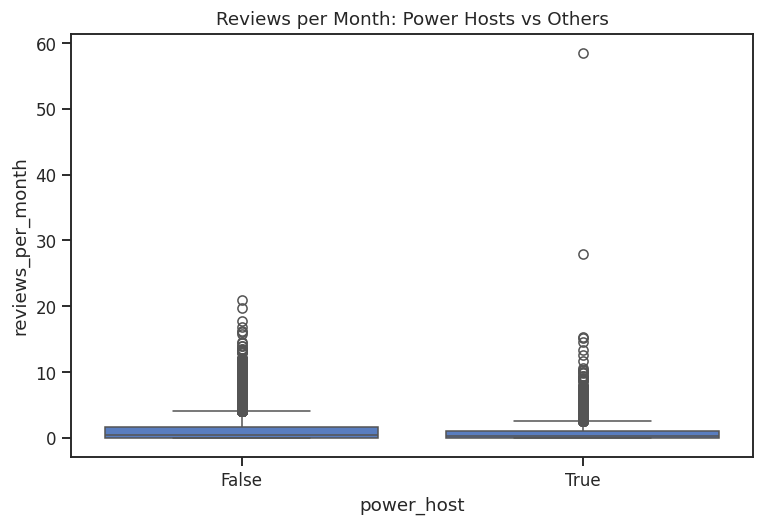

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="power_host",
    y="reviews_per_month",
    data=df
)

plt.title("Reviews per Month: Power Hosts vs Others")

plt.show()

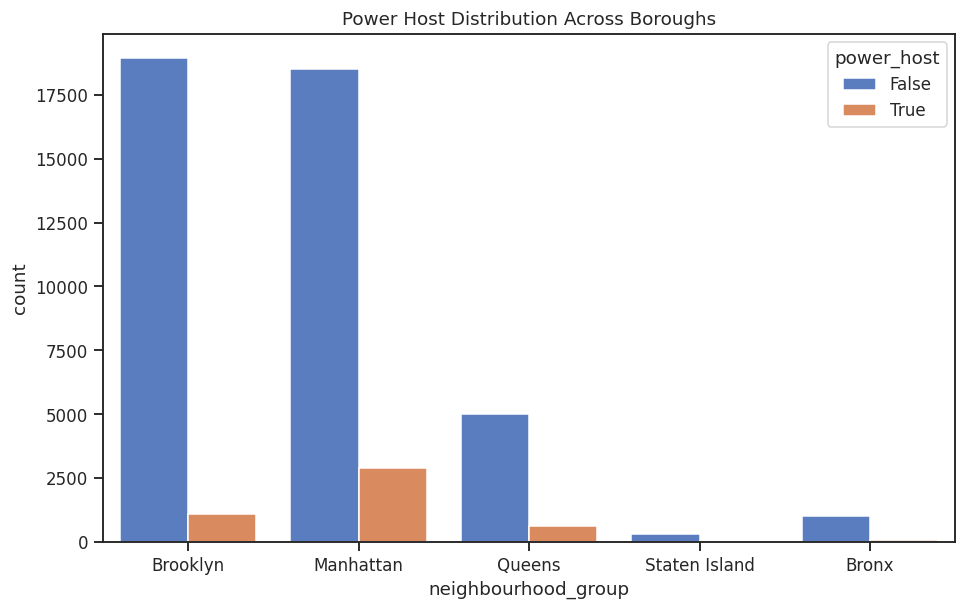

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="neighbourhood_group",
    hue="power_host",
    data=df
)

plt.title("Power Host Distribution Across Boroughs")

plt.show()

In [ ]:
power_host_percentage = df.groupby("neighbourhood_group")["power_host"].mean()*100

power_host_percentage

,power_host
neighbourhood_group,
Bronx,6.813996
Brooklyn,5.411483
Manhattan,13.575062
Queens,11.148469
Staten Island,11.081081


**✍️ Bonus Interpretation:**  

Power hosts were defined as hosts managing more than five listings. The analysis shows that power hosts tend to charge slightly higher prices compared to single-listing hosts, although the difference is not extremely large. This suggests that professional hosts may price their properties competitively despite managing multiple listings. When examining reviews per month, power hosts generally receive similar or slightly higher review activity, indicating that their listings remain attractive to guests. The borough distribution reveals that power hosts are particularly concentrated in Manhattan and Brooklyn, which are the most active Airbnb markets in New York City. This suggests that professional hosting operations tend to focus on high-demand tourist areas where occupancy rates are likely to be higher.


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
